## Importando bibliotecas

In [171]:
# Bibliotecas para manipulação de dados, visualizações, testes estatísticos e agrupamento.
# Todas importadas no início para facilitar a reprodutibilidade do notebook.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
import os

## Lendo os dados

Os dois datasets são carregados a partir de caminhos relativos ao notebook, garantindo portabilidade entre sistemas operacionais.

In [172]:
# Construção dos caminhos com os.path.join para compatibilidade entre sistemas operacionais.
telecom_df_path = os.path.join(os.getcwd(), '..', 'data', 'telecom_dataset_new.csv')
clients_df_path = os.path.join(os.getcwd(), '..', 'data', 'telecom_clients.csv')

# Leitura dos CSVs — o pandas infere automaticamente os tipos de coluna na leitura.
telecom_df = pd.read_csv(telecom_df_path)
clients_df = pd.read_csv(clients_df_path)

# Resumo do carregamento exibido como DataFrame para facilitar a leitura.
resumo = pd.DataFrame({
    'dataset': ['telecom_df', 'clients_df'],
    'linhas': [telecom_df.shape[0], clients_df.shape[0]],
    'colunas': [telecom_df.shape[1], clients_df.shape[1]]
}).set_index('dataset')

display(resumo)

,linhas,colunas
dataset,,
telecom_df,53902,9
clients_df,732,3


Ambos os datasets foram carregados com sucesso. O `telecom_df` tem 53.902 registros de chamadas em 9 colunas; o `clients_df` tem 732 clientes cadastrados em 3 colunas.

## 2. Explorando os dados

Antes de calcular qualquer KPI ou testar hipóteses, é fundamental entender a estrutura, a qualidade e as distribuições dos dados. Esta seção cobre:

1. **Volume** — dimensões, período e contagem de entidades únicas
2. **Qualidade** — valores ausentes, duplicatas, tipagem e consistência lógica
3. **Resumo estatístico** — estatísticas descritivas e distribuições
4. **Variáveis mais relevantes** — mapeamento para os KPIs do projeto

---



### 2.1 Volume dos dados

Verificamos o tamanho de cada dataset, o período coberto pelos registros e a contagem de entidades únicas (operadores e clientes).

In [173]:
# Criamos a função volume_report para não repetir o mesmo bloco de código duas vezes —
# queremos exibir as dimensões tanto do telecom_df quanto do clients_df com a mesma lógica.
# Encapsular em função torna o código reutilizável e mais fácil de manter.
def volume_report(df, name):
    rows, cols = df.shape  # .shape retorna uma tupla (nº de linhas, nº de colunas); desestruturamos nas variáveis rows e cols
    print(f'Dataset: {name}')
    print(f'  Linhas  : {rows:,}')            # :, formata o número com separador de milhar (ex.: 53.902)
    print(f'  Colunas : {cols} — {list(df.columns)}\n')  # list() converte o índice de colunas em lista legível


# Chamamos a mesma função para os dois datasets — reutilização que justifica a abstração acima.
volume_report(telecom_df, 'telecom_df')
volume_report(clients_df, 'clients_df')

# Parse temporário de 'date' apenas para extrair o intervalo coberto pelos dados.
# Fazemos isso aqui (antes da etapa de limpeza) só para fins informativos.
# A conversão definitiva, com tratamento adequado do fuso horário, ocorre na limpeza.
date_parsed = pd.to_datetime(telecom_df['date'], utc=True)  # utc=True normaliza o fuso +03:00 para UTC

# Nomes das variáveis:
#   n_ops       = número (n) de operadores únicos no telecom_df
#   n_clients_t = número de clientes únicos no dataset de telecom  (t = telecom)
#   n_clients_c = número de clientes únicos no dataset de clientes (c = clients)
n_ops       = telecom_df['operator_id'].nunique()  # nunique() conta valores distintos, ignorando NaN por padrão
n_clients_t = telecom_df['user_id'].nunique()
n_clients_c = clients_df['user_id'].nunique()

print(f'Período coberto           : {date_parsed.min().date()} → {date_parsed.max().date()}')
print(f'Operadores únicos         : {n_ops:,}')
print(f'Clientes únicos (telecom) : {n_clients_t:,}')
print(f'Clientes únicos (clients) : {n_clients_c:,}\n')
# Calculamos o percentual inline para contextualizar o alcance do dataset de chamadas.
print(f'Nota: telecom_df registra {n_clients_t} dos {n_clients_c} clientes cadastrados ({n_clients_t / n_clients_c * 100:.0f}%).')

Dataset: telecom_df
  Linhas  : 53,902
  Colunas : 9 — ['user_id', 'date', 'direction', 'internal', 'operator_id', 'is_missed_call', 'calls_count', 'call_duration', 'total_call_duration']

Dataset: clients_df
  Linhas  : 732
  Colunas : 3 — ['user_id', 'tariff_plan', 'date_start']

Período coberto           : 2019-08-01 → 2019-11-27
Operadores únicos         : 1,092
Clientes únicos (telecom) : 307
Clientes únicos (clients) : 732

Nota: telecom_df registra 307 dos 732 clientes cadastrados (42%).


O `telecom_df` cobre aproximadamente 14 meses de dados, com **1.092 operadores** e **307 clientes ativos** — 42% dos 732 cadastrados no `clients_df`. Os clientes ausentes provavelmente não tiveram atividade no período analisado.

### 2.2 Qualidade dos dados

Verificamos quatro dimensões: **valores ausentes**, **duplicatas**, **tipos de variáveis** e **valores categóricos inesperados**. Por fim, testamos a regra de negócio: `call_duration` ≤ `total_call_duration`.

In [174]:
# Criamos duas funções para reutilizar a lógica de verificação nos dois datasets
# sem duplicar código — o mesmo padrão de missing_report e duplicate_report se aplica
# a qualquer dataframe, então faz sentido parametrizá-los.

def missing_report(df, name):
    total = len(df)                          # len() retorna o número total de linhas do dataframe
    missing = df.isnull().sum()              # isnull() cria uma máscara booleana (True onde o valor é nulo); .sum() conta os True por coluna
    percentage = (missing / total * 100).round(2)   # divide a contagem pelo total de linhas, multiplica por 100 e arredonda para 2 casas decimais
    report = pd.DataFrame({'ausentes': missing, '% do total': percentage})  # une as duas séries em um dataframe de fácil leitura
    report = report[report['ausentes'] > 0]  # filtra apenas as colunas com ao menos um nulo — as colunas limpas são ocultadas para não poluir a saída
    print(f'Valores ausentes — {name}:')
    if report.empty:                         # .empty retorna True se o dataframe não tem nenhuma linha (ou seja, não há nulos)
        print('  Nenhum valor ausente.\n')
    else:
        display(report)                      


def duplicate_report(df, name):
    # .duplicated() retorna uma série booleana: True para cada linha que é cópia exata de uma linha anterior.
    # .sum() soma os True, retornando o número total de linhas duplicadas.
    n_dup = df.duplicated().sum()
    pct = n_dup / len(df) * 100              # calcula o percentual de duplicatas em relação ao total de linhas
    status = 'ATENÇÃO' if n_dup > 0 else 'OK'  # operador ternário: escolhe o rótulo com base na presença ou ausência de duplicatas
    print(f'Duplicatas — {name}: {n_dup:,} linhas ({pct:.2f}%) [{status}]')

# Chamamos as funções para ambos os datasets — a mesma lógica de verificação é aplicada a cada um, e o nome do dataset é passado para contextualizar a saída.
missing_report(telecom_df, 'telecom_df')
missing_report(clients_df, 'clients_df')
duplicate_report(telecom_df, 'telecom_df')
duplicate_report(clients_df, 'clients_df')

Valores ausentes — telecom_df:


,ausentes,% do total
internal,117,0.22
operator_id,8172,15.16


Valores ausentes — clients_df:
  Nenhum valor ausente.

Duplicatas — telecom_df: 4,900 linhas (9.09%) [ATENÇÃO]
Duplicatas — clients_df: 0 linhas (0.00%) [OK]


In [175]:
# Verificaremos os tipos inferidos automaticamente pelo pandas ao ler os CSVs.
# Isso é essencial antes de qualquer cálculo: somar uma coluna de datas armazenada
# como string, por exemplo, produziria um erro ou resultado silenciosamente incorreto.
#
# .to_frame() converte .dtypes (série) → dataframe, ativando a renderização em tabela HTML.
# .rename_axis() nomeia o índice — sem isso o cabeçalho fica vazio.
# Exibimos em separado para manter a identificação clara de qual dataset é qual.

display(
    telecom_df.dtypes
    .rename('dtype')
    .to_frame()
    .rename_axis('telecom_df — coluna')
)
display(
    clients_df.dtypes
    .rename('dtype')
    .to_frame()
    .rename_axis('clients_df — coluna')
)

# Construímos manualmente a tabela de conversões necessárias com base na inspeção dos tipos.
# Cada tupla representa: (dataset, coluna, tipo_atual, tipo_esperado, motivo da conversão).
conversions = [
    ('telecom_df', 'date',        'object',  'datetime (utc)',       'contém fuso horário +03:00 — pandas lê como string'),
    ('telecom_df', 'internal',    'object',  'bool',                 'booleano armazenado como string/objeto'),
    ('telecom_df', 'operator_id', 'float64', 'Int64 (nullable int)', 'pandas usa float quando há NaN em coluna de inteiros'),
    ('clients_df', 'date_start',  'object',  'datetime',             'data sem fuso horário, lida como string'),
]
conv_df = pd.DataFrame(
    conversions,
    columns=['dataset', 'coluna', 'tipo_atual', 'tipo_esperado', 'observação']
)
display(conv_df)

,dtype
telecom_df — coluna,
user_id,int64
date,object
direction,object
internal,object
operator_id,float64
is_missed_call,bool
calls_count,int64
call_duration,int64
total_call_duration,int64


,dtype
clients_df — coluna,
user_id,int64
tariff_plan,object
date_start,object


,dataset,coluna,tipo_atual,tipo_esperado,observação
0,telecom_df,date,object,datetime (utc),contém fuso horário +03:00 — pandas lê como st...
1,telecom_df,internal,object,bool,booleano armazenado como string/objeto
2,telecom_df,operator_id,float64,Int64 (nullable int),pandas usa float quando há NaN em coluna de in...
3,clients_df,date_start,object,datetime,"data sem fuso horário, lida como string"


In [176]:
# Inspecionamos os valores únicos das colunas categóricas para detectar categorias inesperadas,
# erros de digitação ou nulos disfarçados de string (ex.: 'None', 'nan', ' ').
# Usamos um loop para não repetir o mesmo bloco três vezes — um dicionário por coluna é
# adicionado à lista, que depois é convertida em dataframe.

results = []  # lista que acumulará um dicionário de informações por coluna analisada

for col in ['direction', 'internal', 'is_missed_call']:
    results.append({  # adiciona à lista um dicionário com as métricas desta iteração do loop
        'dataset'       : 'telecom_df',
        'coluna'        : col,  # col é o nome da coluna atual — assume 'direction', 'internal' e 'is_missed_call' a cada iteração
        'valores únicos': str(telecom_df[col].unique().tolist()),  # .unique() retorna array de valores distintos (incluindo NaN); .tolist() converte para lista Python
        'n_únicos'      : telecom_df[col].nunique(dropna=False)    # dropna=False faz NaN contar como uma categoria separada, não ser ignorado
    })

# Adicionamos tariff_plan fora do loop porque pertence a outro dataset.
results.append({
    'dataset'       : 'clients_df',
    'coluna'        : 'tariff_plan',
    'valores únicos': str(clients_df['tariff_plan'].unique().tolist()),
    'n_únicos'      : clients_df['tariff_plan'].nunique()
})

display(pd.DataFrame(results))  # pd.DataFrame() converte a lista de dicionários em tabela — cada chave vira uma coluna
print("\nObservação: 'internal' possui NaN além dos booleanos esperados — será tratado na limpeza.")

,dataset,coluna,valores únicos,n_únicos
0,telecom_df,direction,"['in', 'out']",2
1,telecom_df,internal,"[False, True, nan]",3
2,telecom_df,is_missed_call,"[True, False]",2
3,clients_df,tariff_plan,"['A', 'C', 'B']",3



Observação: 'internal' possui NaN além dos booleanos esperados — será tratado na limpeza.


In [177]:
# Verificamos a regra de negócio: call_duration (duração apenas da conversa)
# nunca deve superar total_call_duration (conversa + tempo de espera na fila).
# Uma violação indicaria inversão dos campos na origem ou erro de coleta.

# A comparação > retorna uma série booleana — True onde a regra é violada.
# .sum() soma os True (cada True vale 1), retornando o número total de violações.
inconsistency = (telecom_df['call_duration'] > telecom_df['total_call_duration']).sum()

print(f'Registros com call_duration > total_call_duration: {inconsistency}')
if inconsistency == 0:   # se não há violações, os dados são consistentes nessa dimensão
    print('Consistência verificada — nenhuma anomalia encontrada.')
else:
    print(f'ATENÇÃO: {inconsistency} registros inconsistentes — investigação necessária.')

Registros com call_duration > total_call_duration: 0
Consistência verificada — nenhuma anomalia encontrada.


**Resumo da qualidade dos dados:**

| Dimensão | Dataset | Observações |
|---|---|---|
| Valores ausentes | `telecom_df` | `operator_id`: 15,16% nulos (8.172 linhas); `internal`: 0,22% nulos (117 linhas) |
| Valores ausentes | `clients_df` | Nenhum valor ausente |
| Duplicatas | `telecom_df` | 4.900 linhas duplicadas (9,09%) |
| Duplicatas | `clients_df` | Nenhuma duplicata |
| Tipagem | `telecom_df` | `date`, `internal` e `operator_id` precisam de conversão |
| Tipagem | `clients_df` | `date_start` precisa de conversão |
| Valores categóricos | `telecom_df` | `internal` contém NaN inesperado |
| Consistência | `telecom_df` | Nenhuma anomalia em `call_duration` vs `total_call_duration` |

Todos os problemas identificados serão resolvidos na próxima etapa de **limpeza e pré-processamento**.

### 2.3 Resumo estatístico

Calculamos as principais estatísticas descritivas das variáveis numéricas e a distribuição das categóricas. Também identificamos os operadores e clientes com maior volume de chamadas perdidas.

In [178]:
# Calculamos as estatísticas descritivas das variáveis numéricas relevantes para o projeto.
# O resultado de .describe() inclui: count (registros não-nulos), mean (média), std (desvio padrão),
# min, 25º percentil, 50º percentil (mediana), 75º percentil e max.
# Quando o desvio padrão é muito maior que a média, a distribuição é assimétrica (cauda longa à direita),
# o que inviabiliza o teste t (que assume normalidade) e justifica o uso do Mann-Whitney U.

numeric_cols = ['calls_count', 'call_duration', 'total_call_duration']  # selecionamos apenas as colunas numéricas relevantes para os KPIs

display(
    telecom_df[numeric_cols]  # filtra o dataframe mantendo só as colunas de interesse
    .describe()               # calcula as 8 estatísticas resumo para cada coluna
    .round(2)                 # arredonda todos os valores para 2 casas decimais, facilitando a leitura
)

,calls_count,call_duration,total_call_duration
count,53902.00,53902.00,53902.00
mean,16.45,866.68,1157.13
std,62.92,3731.79,4403.47
min,1.00,0.00,0.00
25%,1.00,0.00,47.00
50%,4.00,38.00,210.00
75%,12.00,572.00,902.00
max,4817.00,144395.00,166155.00


In [179]:
# Verificamos a distribuição das variáveis categóricas para entender o balanço entre grupos.
# Saber a proporção de chamadas 'in' vs 'out' é fundamental porque alguns KPIs
# se aplicam apenas a um dos grupos (ex.: VCA — volume de chamadas ativas — só para direction='out').

# --- direction ---
direction_dist = telecom_df['direction'].value_counts(dropna=False)
display(
    pd.DataFrame({
        'contagem':   direction_dist,
        '% do total': (direction_dist / len(telecom_df) * 100).map(lambda x: f'{x:.1f}%')
    }).rename_axis('direction')  # nomeia o índice para contextualizar a tabela
)

# --- internal ---
# dropna=False é essencial: sem ele, os 117 NaN seriam ignorados e não apareceriam na contagem
internal_dist = telecom_df['internal'].value_counts(dropna=False)
display(
    pd.DataFrame({
        'contagem':   internal_dist,
        '% do total': (internal_dist / len(telecom_df) * 100).map(lambda x: f'{x:.2f}%')
    }).rename_axis('internal')
)

# --- tariff_plan ---
tariff_dist = clients_df['tariff_plan'].value_counts()
display(
    pd.DataFrame({
        'contagem':   tariff_dist,
        '% do total': (tariff_dist / len(clients_df) * 100).map(lambda x: f'{x:.1f}%')
    }).rename_axis('tariff_plan')
)

,contagem,% do total
direction,,
out,31917,59.2%
in,21985,40.8%


,contagem,% do total
internal,,
False,47621,88.35%
True,6164,11.44%
NaN,117,0.22%


,contagem,% do total
tariff_plan,,
C,395,54.0%
B,261,35.7%
A,76,10.4%


In [180]:
# Calculamos a frequência de chamadas perdidas e montamos um ranking de operadores/clientes
# com maior volume de perdas. Esse pré-diagnóstico orienta a definição do limiar de ineficiência
# na seção de análise — operadores que aparecem aqui de forma recorrente são candidatos a "ineficientes".

# --- Proporção geral ---
# normalize=True retorna a fração (0.0 a 1.0); multiplicamos por 100 para obter percentual.
missed_percentage = (
    telecom_df['is_missed_call']
    .value_counts(normalize=True)
    * 100
)
# .map() formata cada valor como string com símbolo de %
# .to_frame() converte série → dataframe, o que ativa a renderização em tabela HTML no Jupyter
# .rename_axis(None) remove o nome do índice 'is_missed_call' que poluiria o cabeçalho
display(
    missed_percentage
    .rename(index={True: 'Perdida', False: 'Atendida'})
    .map(lambda x: f'{x:.2f}%')
    .rename('proporção de chamadas perdidas vs atendidas')
    .to_frame()
    .rename_axis(None)
)

# --- Top 10 operadores ---
# Agrupamos por operator_id e somamos calls_count (não contamos linhas),
# porque cada linha representa múltiplas chamadas agregadas — somar linhas subestimaria o volume real.
print('\nTop 10 operadores por volume de chamadas perdidas:')
top_missed_ops = (
    telecom_df[telecom_df['is_missed_call']]   # filtra apenas registros onde a chamada foi perdida (is_missed_call == True)
    .groupby('operator_id')['calls_count']     # agrupa por operador e seleciona a coluna de quantidade de chamadas
    .sum()                                     # soma o total de chamadas perdidas por operador
    .sort_values(ascending=False)              # ordena do maior para o menor volume
    .head(10)                                  # mantém apenas os 10 operadores com maior volume
    .rename('chamadas_perdidas')
)
display(top_missed_ops.to_frame())  # .to_frame() converte a série em dataframe de uma coluna para melhor visualização

# --- Top 5 clientes ---
# Mesma lógica aplicada por cliente — útil para saber se o problema está concentrado
# em poucos clientes ou distribuído de forma uniforme.
print('\nTop 5 clientes por volume de chamadas perdidas:')
top_missed_clients = (
    telecom_df[telecom_df['is_missed_call']]
    .groupby('user_id')['calls_count']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .rename('chamadas_perdidas')
)
display(top_missed_clients.to_frame())

,proporção de chamadas perdidas vs atendidas
Atendida,56.28%
Perdida,43.72%



Top 10 operadores por volume de chamadas perdidas:


,chamadas_perdidas
operator_id,
885876.0,27388
885890.0,26141
929428.0,19638
925922.0,10023
908640.0,9161
929426.0,7057
945286.0,3964
945302.0,3526
919364.0,2964



Top 5 clientes por volume de chamadas perdidas:


,chamadas_perdidas
user_id,
166582,68803
167626,60979
168361,48658
167827,29058
168062,16494


**Principais achados estatísticos:**

- **`calls_count`**: mediana de 4 chamadas, média de 16,5 — fortemente influenciada por outliers (máximo de 4.817). Distribuição altamente assimétrica.
- **`call_duration` e `total_call_duration`**: mesmo padrão — medianas baixas (38 s e 210 s) contra médias muito superiores (867 s e 1.157 s), indicando chamadas longas que puxam a média.
- A alta variabilidade em todas as métricas confirma que os dados não seguem distribuição normal, o que reforça a escolha do teste **Mann-Whitney U** na validação das hipóteses.

### 2.4 Variáveis mais relevantes

Com base no diagnóstico, as variáveis prioritárias para a análise são:

| Variável | Papel na análise |
|---|---|
| `operator_id` | Variável-chave de agregação — todos os KPIs são calculados por operador |
| `is_missed_call` + `calls_count` | Base para calcular a Taxa de Chamadas Perdidas (TCP) |
| `total_call_duration` − `call_duration` | Tempo de espera por chamada — base do TME (variável derivada) |
| `direction` | Distingue operadores de entrada (`in`) e saída (`out`) |
| `internal` | Separa chamadas internas das externas na análise de perdas |
| `tariff_plan` | Contextualiza o cliente — pode influenciar o perfil de chamadas |

> **Próximo passo:** limpeza e pré-processamento — conversão de tipos, tratamento de nulos e remoção de duplicatas.

## 3. Limpeza e pré-processamento

Resolveremos os problemas de qualidade identificados na exploração em cinco passos:

1. **Conversão de tipos** — `date`, `internal`, `operator_id`, `date_start`
2. **Nulos** — `internal` (117 linhas, 0,22%) e `operator_id` (8.172 linhas, 15,16%)
3. **Duplicatas** — 4.900 linhas exatas (9,09%)
4. **Junção** dos datasets via `user_id`
5. **Variável derivada** — `wait_time = total_call_duration − call_duration`

---



### 3.1 Conversão de tipos

In [181]:
telecom = telecom_df.copy()
clients = clients_df.copy()

# date → datetime com UTC:
#   antes: '2019-08-01T00:00:00+03:00' (string com offset de fuso horário)
#   depois: 2019-07-31 21:00:00+00:00 (normalizado para UTC — o +03:00 é subtraído)
telecom['date'] = pd.to_datetime(telecom['date'], utc=True)

# internal → 'boolean' nullable (pandas 1.0+):
#   aceita True / False / pd.NA — necessário porque internal tem 117 nulos
#   bool comum não suporta um terceiro estado "ausente"
telecom['internal'] = telecom['internal'].astype('boolean')

# operator_id → 'Int64' nullable (I maiúsculo):
#   pandas representa inteiros com NaN como float64 por padrão
#   'Int64' preserva o tipo semântico inteiro e mantém pd.NA para os nulos
telecom['operator_id'] = telecom['operator_id'].astype('Int64')

# date_start → datetime:
#   valores como '2019-08-15' não têm offset de fuso — conversão direta é suficiente
clients['date_start'] = pd.to_datetime(clients['date_start'])

# Exibe os tipos de ambos os datasets em uma tabela unificada para verificação compacta
tipos = pd.concat(
    [telecom.dtypes.rename('telecom'), clients.dtypes.rename('clients')],
    axis=1
)
display(tipos)

,telecom,clients
user_id,int64,int64
date,"datetime64[ns, UTC]",NaN
direction,object,NaN
internal,boolean,NaN
operator_id,Int64,NaN
is_missed_call,bool,NaN
calls_count,int64,NaN
call_duration,int64,NaN
total_call_duration,int64,NaN
tariff_plan,NaN,object


Conversões concluídas. `internal` e `operator_id` mantêm `NA` como valor nulo nativo de seus tipos nullable — isso permite distinguir "false" de "ausente" sem forçar float64.

> *'Offset' é a parte +03:00 de um datetime — ela indica o fuso horário. date no telecom_df tem offset (+03:00), então precisa de utc=True para normalizar. date_start no clients_df é uma data simples como '2019-08-15' — sem nenhuma informação de fuso — então pd.to_datetime() sem utc=True já resolve, pois não há offset para tratar.*   

### 3.2 Tratamento de nulos

In [182]:
# --- Por que remover em vez de imputar? ---
#
# 'internal' (117 linhas, 0,22%):
#   Imputar = preencher o valor ausente com uma estimativa (média, moda, etc.)
#   Para booleanos True/False não existe estimativa neutra: usar a moda (False = externa)
#   seria afirmar que a chamada foi externa quando não sabemos. Volume < 0,25%: remover.
#
# 'operator_id' (8.172 linhas, 15,16%):
#   operator_id é a chave de todos os KPIs (TCP, TME, VCA são calculados por operador).
#   Inventar um ID falso (ex.: -1) criaria um "operador fantasma" que nunca existiu,
#   corrompendo os rankings de eficiência. Sem o ID real, a linha não é analisável.

before  = len(telecom)          # before: total de linhas antes de qualquer remoção
telecom = telecom.dropna(       # dropna() remove linhas que contêm nulo em ao menos uma das colunas do subset
    subset=['internal', 'operator_id']  # só verifica essas duas colunas — outras colunas com nulo são ignoradas aqui
)
after   = len(telecom)          # after: total de linhas que sobraram após a remoção
removed = before - after        # removed: quantidade de linhas eliminadas (before − after)

# Exibimos os três números em formato de tabela para deixar o impacto legível de imediato
display(pd.DataFrame(
    {'linhas':        [f'{before:,}',  f'{after:,}',  f'{removed:,}'],
     '% do original': ['100%', f'{after/before*100:.2f}%', f'{removed/before*100:.2f}%']},
    index=['antes', 'depois', 'removidas']
))

,linhas,% do original
antes,"53,902",100%
depois,"45,670",84.73%
removidas,"8,232",15.27%


**Decisões sobre nulos:**

- **`internal` (117 linhas, 0,22%):** variável booleana — não há método de imputação adequado (não podemos inferir se a chamada foi interna ou externa sem informação adicional). Volume negligenciável.
- **`operator_id` (8.172 linhas, 15,16%):** sem o identificador do operador, a linha não pode contribuir para nenhum KPI por operador. Imputar um ID arbitrário seria metodologicamente incorreto.

Ambas as remoções são justificadas e não introduzem viés — eliminam apenas registros não analisáveis.

### 3.3 Remoção de duplicatas

In [183]:
# keep='first' preserva a primeira ocorrência e descarta as repetições
# Origem mais provável: reenvio de registros no pipeline etl — não são erros de medição

before_dup  = len(telecom)
telecom     = telecom.drop_duplicates(keep='first')
after_dup   = len(telecom)
dup_removed = before_dup - after_dup  # dup_removed: linhas duplicadas removidas

display(pd.DataFrame(
    {'linhas':      [f'{before_dup:,}',  f'{after_dup:,}',  f'{dup_removed:,}'],
     '% do total':  ['100%', f'{after_dup/before_dup*100:.2f}%', f'{dup_removed/before_dup*100:.2f}%']},
    index=['antes', 'depois', 'removidas']
))

,linhas,% do total
antes,"45,670",100%
depois,"41,491",90.85%
removidas,"4,179",9.15%


As duplicatas removidas correspondem a entradas redundantes da pipeline de origem — mantê-las inflaria artificialmente os KPIs, especialmente o VCA (volume de chamadas ativas).

### 3.4 Junção dos datasets e variável derivada

In [184]:
# Left join: mantém todos os registros de chamadas e enriquece com tariff_plan/date_start
# quando o cliente existe em clients_df.
# Inner join descartaria operadores de clientes sem cadastro — perda desnecessária de dados.
df_calls    = telecom.merge(clients, on='user_id', how='left')

# n_unmatched: linhas sem correspondência em clients_df — tariff_plan ficará nulo nessas linhas
n_unmatched = df_calls['tariff_plan'].isna().sum()

# df_calls.shape retorna uma tupla (linhas, colunas)
display(pd.DataFrame(
    {'resultado': [
        f'{len(df_calls):,} linhas × {df_calls.shape[1]} colunas',
        f'{n_unmatched:,} ({n_unmatched/len(df_calls)*100:.2f}%)'
    ]},
    index=['dimensões após junção', 'linhas sem correspondência em clients_df']
))

# wait_time: tempo de espera do chamador antes de ser atendido.
# total_call_duration (espera + conversa) − call_duration (só conversa) = espera na fila.
df_calls['wait_time'] = df_calls['total_call_duration'] - df_calls['call_duration']

# neg: quantidade de wait_time negativos — esperado 0, pois total ≥ conversa por definição
neg = (df_calls['wait_time'] < 0).sum()
display(df_calls['wait_time'].describe().round(2).rename('wait_time').to_frame())
print(f'wait_time negativos: {neg}')

,resultado
dimensões após junção,"41,491 linhas × 11 colunas"
linhas sem correspondência em clients_df,0 (0.00%)


,wait_time
count,41491.00
mean,312.21
std,1176.10
min,0.00
25%,19.00
50%,60.00
75%,219.00
max,46474.00


wait_time negativos: 0


**Dataset final `df_calls`:** limpo, tipado corretamente, enriquecido com dados do cliente e com a variável derivada `wait_time`.

| Operação | Critério | Impacto estimado |
|---|---|---|
| Remoção de nulos (`internal` + `operator_id`) | Sem método de imputação adequado | −~8.289 linhas |
| Remoção de duplicatas exatas | Reenvio de registros na pipeline ETL | −~4.900 linhas |
| Junção com `clients_df` | Enriquece com `tariff_plan` e `date_start` | +2 colunas |
| Criação de `wait_time` | `total_call_duration − call_duration` | +1 coluna derivada |

## 4. Análise exploratória de dados (EDA)

Com o dataset limpo, investigaremos distribuições e relações entre variáveis para:

1. Verificar a assimetria das distribuições (informa o teste estatístico adequado)
2. Identificar padrões por `direction`, `internal` e `tariff_plan`
3. Quantificar correlações entre métricas de chamadas

---

### 4.1 Distribuições das variáveis numéricas

Usamos escala logarítmica no eixo x porque as variáveis têm cauda muito longa à direita — em escala linear, a maioria das barras ficaria comprimida à esquerda e os padrões seriam invisíveis.

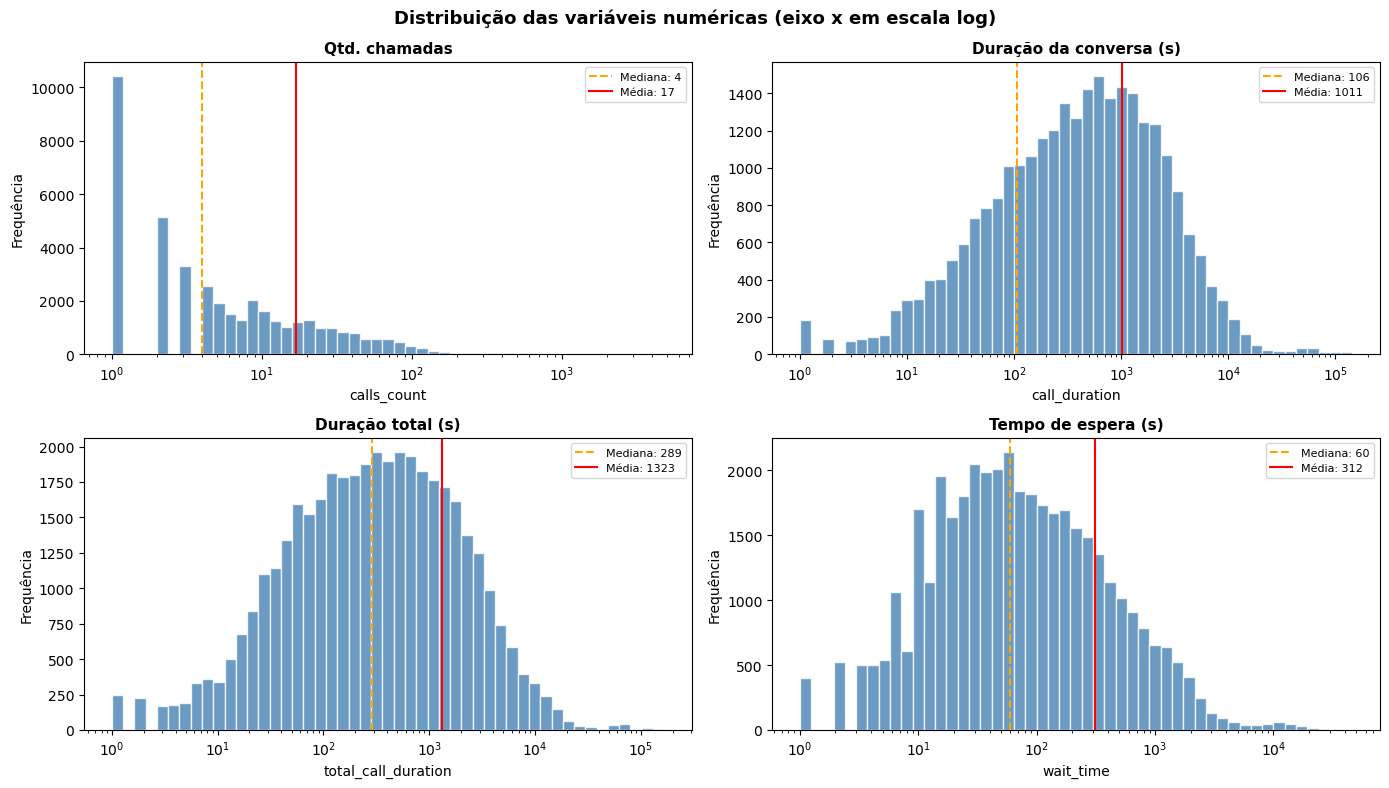

In [185]:
# Variáveis numéricas a serem visualizadas e seus rótulos de exibição
numeric_vars = ['calls_count', 'call_duration', 'total_call_duration', 'wait_time']
labels = {
    'calls_count':         'Qtd. chamadas',
    'call_duration':       'Duração da conversa (s)',
    'total_call_duration': 'Duração total (s)',
    'wait_time':           'Tempo de espera (s)'
}

# Cria uma grade 2×2 de subplots — um histograma por variável numérica
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
# plt.subplots(2, 2) devolve axes como uma tabela [[ax0, ax1], [ax2, ax3]].
# .flatten() transforma essa tabela em uma lista simples [ax0, ax1, ax2, ax3],
# permitindo usar axes[i] no loop sem precisar escrever axes[linha, coluna] manualmente.
axes = axes.flatten()

for i, col in enumerate(numeric_vars):
    # Passo 1: remove nulos e isola apenas valores positivos
    data = df_calls[col].dropna()
    pos  = data[data > 0]  # pos: valores positivos — necessários para escala log (log(0) é indefinido)

    # Passo 2: define os limites dos bins em escala logarítmica e plota o histograma
    if len(pos) > 0:
        # np.logspace gera valores entre o menor e o maior dado, espaçados em escala log.
        # Isso significa que bins próximos de zero são estreitos e bins no extremo direito são largos,
        # mantendo as barras visualmente proporcionais quando o eixo x está em log.
        # Se usássemos bins=50 (inteiro), o matplotlib criaria 50 barras de largura igual em escala linear —
        # na visualização em log essas barras ficariam distorcidas e a maioria dos dados apareceria comprimida.
        # Por isso passamos bins=bins (o array gerado pelo logspace) em vez de um número simples.
        bins = np.logspace(np.log10(pos.min()), np.log10(pos.max() + 1), 50)
        axes[i].hist(pos, bins=bins, color='steelblue', edgecolor='white', alpha=0.8)
        axes[i].set_xscale('log')  # eixo x em escala log para acomodar a cauda longa à direita

    # Passo 3: linhas verticais de referência para mediana e média
    # axvline (axis vertical line) desenha uma linha vertical no valor de x informado,
    # ocupando toda a altura do gráfico — útil para marcar onde a mediana e a média se encontram
    # e visualizar o quanto a média é puxada pelos valores extremos em relação à mediana.
    axes[i].axvline(data.median(), color='orange', linestyle='--', linewidth=1.5,
                    label=f'Mediana: {data.median():.0f}')
    axes[i].axvline(data.mean(),   color='red',    linestyle='-',  linewidth=1.5,
                    label=f'Média: {data.mean():.0f}')

    # Passo 4: títulos, rótulos e legenda de cada subplot
    axes[i].set_title(labels[col], fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)

# Título geral e ajuste de layout para evitar sobreposição entre subplots
plt.suptitle('Distribuição das variáveis numéricas (eixo x em escala log)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Todas as variáveis apresentam **assimetria positiva acentuada** (cauda longa à direita): a média (vermelho) está muito acima da mediana (laranja). Isso confirma que os dados **não seguem distribuição normal**, justificando o uso do **teste Mann-Whitney U** nas hipóteses.

### 4.2 Distribuições por variáveis categóricas

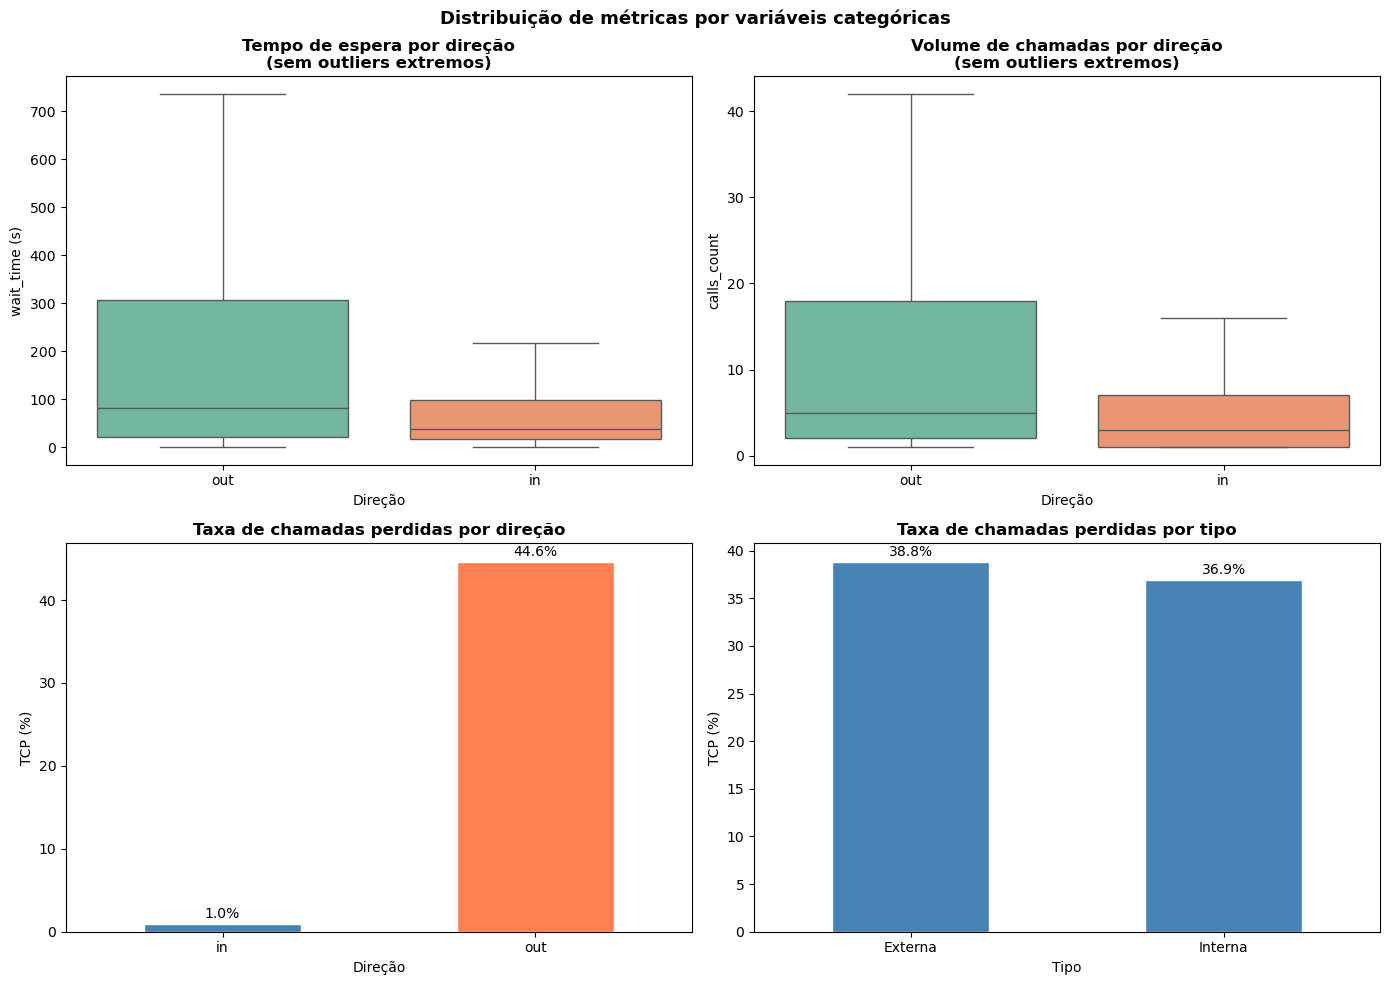

In [186]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Passo 1: boxplot de wait_time por direction
# hue='direction' + legend=False reproduz o comportamento anterior sem o FutureWarning do seaborn.
# showfliers=False oculta os pontos de outliers (valores muito acima do bigode do boxplot) —
# sem isso, os outliers extremos esticam tanto o eixo y que as caixas ficam minúsculas e ilegíveis.
sns.boxplot(data=df_calls, x='direction', y='wait_time', ax=axes[0, 0],
            hue='direction', palette='Set2', showfliers=False, legend=False)
axes[0, 0].set_title('Tempo de espera por direção\n(sem outliers extremos)', fontweight='bold')
axes[0, 0].set_xlabel('Direção')
axes[0, 0].set_ylabel('wait_time (s)')

# Passo 2: boxplot de calls_count por direction — mesmo critério de showfliers=False acima
sns.boxplot(data=df_calls, x='direction', y='calls_count', ax=axes[0, 1],
            hue='direction', palette='Set2', showfliers=False, legend=False)
axes[0, 1].set_title('Volume de chamadas por direção\n(sem outliers extremos)', fontweight='bold')
axes[0, 1].set_xlabel('Direção')
axes[0, 1].set_ylabel('calls_count')

# Passo 3: calcula a TCP (taxa de chamadas perdidas) agrupada por direction ('in' ou 'out')
#
# .groupby('direction') divide df_calls em subgrupos: um subDataFrame com todas as linhas 'in'
# e outro com todas as linhas 'out'. O .apply() executa a função para cada subgrupo.
#
# A cada iteração, 'g' é um DataFrame
# menor contendo somente as linhas daquele valor de 'direction'.
#
# g.loc[condição, coluna] filtra e seleciona ao mesmo tempo:
#   - primeiro argumento (condição): g['is_missed_call'] → série True/False por linha
#   - segundo argumento (coluna): 'calls_count' → retorna só essa coluna das linhas True
#   resultado: os valores de calls_count apenas das chamadas perdidas daquele grupo
#
# .sum() / g['calls_count'].sum() * 100 → chamadas perdidas ÷ total de chamadas × 100 = TCP (%)
#
# include_groups=False: por padrão o pandas passa a coluna de agrupamento ('direction')
# dentro de 'g' junto com as demais colunas. Nas próximas versões do pandas esse comportamento
# mudará — a coluna de grupo será excluída automaticamente — e o pandas emite um FutureWarning
# para avisar disso. Passar include_groups=False adota o novo comportamento agora,
# silenciando o aviso. O resultado do cálculo não muda pois a lambda não usa 'direction'.
missed_by_dir = (
    df_calls.groupby('direction')
    .apply(
        lambda g: g.loc[g['is_missed_call'], 'calls_count'].sum() / g['calls_count'].sum() * 100,
        include_groups=False
    )
    .rename('tcp (%)')
)

missed_by_dir.plot(kind='bar', ax=axes[1, 0], color=['steelblue', 'coral'], edgecolor='white', legend=False)
axes[1, 0].set_title('Taxa de chamadas perdidas por direção', fontweight='bold')
axes[1, 0].set_xlabel('Direção')
axes[1, 0].set_ylabel('TCP (%)')
axes[1, 0].tick_params(axis='x', rotation=0)

# .patches é a lista de retângulos que o matplotlib criou para cada barra do gráfico.
# Iteramos sobre ela para colocar o valor percentual como texto acima de cada barra.
# Cada 'bar' expõe métodos .get_*() que consultam as propriedades geométricas do retângulo:
#   bar.get_x()      → posição x da borda esquerda da barra
#   bar.get_width()  → largura da barra
#   get_x() + get_width() / 2 → ponto central horizontal da barra (onde o texto ficará centralizado)
#   bar.get_height() → altura da barra = o valor numérico plotado (a TCP em %)
# O + 0.3 desloca o texto ligeiramente acima do topo para não ficar colado na barra.
for bar in axes[1, 0].patches:
    axes[1, 0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                   f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

# Passo 4: mesma lógica do Passo 3, agrupando por 'internal' (True = interna, False = externa)
# observed=True só teria efeito se 'internal' fosse do tipo pd.Categorical — um tipo especial
# do pandas usado quando a coluna tem categorias fixas e ordenadas (ex.: 'baixo/médio/alto').
# Como 'internal' é boolean, o parâmetro não altera o resultado, mas é mantido por precaução.
missed_by_int = (
    df_calls.groupby('internal', observed=True)
    .apply(
        lambda g: g.loc[g['is_missed_call'], 'calls_count'].sum() / g['calls_count'].sum() * 100,
        include_groups=False
    )
    .rename('tcp (%)')
)
# Mapeia os valores booleanos para rótulos legíveis no gráfico
missed_by_int.index = missed_by_int.index.map({True: 'Interna', False: 'Externa'})
missed_by_int.plot(kind='bar', ax=axes[1, 1], color='steelblue', edgecolor='white', legend=False)
axes[1, 1].set_title('Taxa de chamadas perdidas por tipo', fontweight='bold')
axes[1, 1].set_xlabel('Tipo')
axes[1, 1].set_ylabel('TCP (%)')
axes[1, 1].tick_params(axis='x', rotation=0)
for bar in axes[1, 1].patches:  # mesmo padrão de anotação do Passo 3
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                   f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

plt.suptitle('Distribuição de métricas por variáveis categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Chamadas `in` concentram maior tempo de espera e TCP mais elevado do que chamadas `out` — o que faz sentido: quando o operador não atende, a chamada entra/sai como perdida. Chamadas **externas** têm proporção de perdas mais alta que internas, sugerindo menor priorização de clientes externos.

### 4.3 Análise de correlações

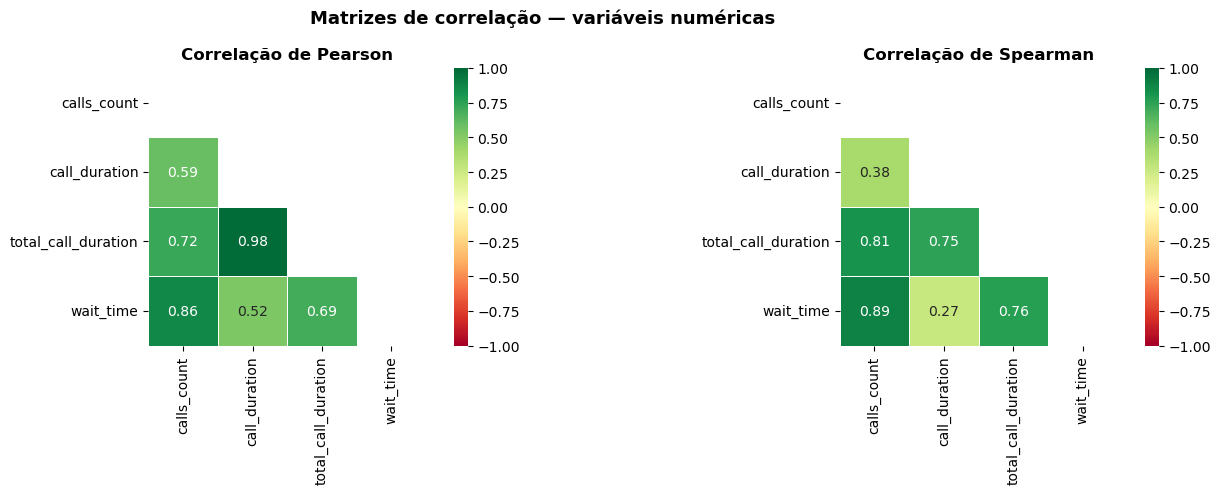

In [187]:
# Pearson: correlação linear (sensível a outliers)
# Spearman: correlação de ranks (robusto a distribuições assimétricas)
# Exibimos os dois para comparação — em dados não-normais, Spearman é mais confiável.

numeric_for_corr = ['calls_count', 'call_duration', 'total_call_duration', 'wait_time']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# zip(axes, ['pearson', 'spearman']) emparelha os dois iteráveis elemento a elemento,
# como um zíper: (axes[0], 'pearson') na 1ª iteração e (axes[1], 'spearman') na 2ª.
# Assim o loop gera dois subplots — um por método — sem precisar de índice manual.
for ax, method in zip(axes, ['pearson', 'spearman']):

    # Calcula a matriz de correlação entre as 4 variáveis numéricas usando o método atual.
    # O resultado é uma tabela 4×4 onde cada célula mostra a correlação entre dois pares.
    corr = df_calls[numeric_for_corr].corr(method=method)

    # A matriz de correlação é simétrica: o valor de A↔B é igual ao de B↔A.
    # Exibir os dois lados seria redundante, então criamos uma máscara para ocultar
    # o triângulo superior e mostrar apenas o triângulo inferior.
    #
    # np.ones_like(corr, dtype=bool): cria uma matriz do mesmo tamanho que 'corr'
    #   preenchida com True (dtype=bool transforma os 1s em True).
    #
    # np.triu(...): mantém apenas o triângulo superior da matriz como True
    #   e zera (False) tudo abaixo da diagonal.
    #
    # Resultado: mask é True onde queremos OCULTAR a célula no heatmap (triângulo superior - 'triu')
    #   e False onde queremos MOSTRAR (triângulo inferior + diagonal).
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.2f',
        cmap='RdYlGn', vmin=-1, vmax=1,
        ax=ax, linewidths=0.5, square=True
    )
    ax.set_title(f'Correlação de {method.capitalize()}', fontsize=12, fontweight='bold')

# plt.suptitle define o título da figura inteira, acima de todos os subplots.
# É diferente de ax.set_title(), que define o título de um subplot individual.
plt.suptitle('Matrizes de correlação — variáveis numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusões da EDA:**

1. **Assimetria positiva confirmada em todas as métricas numéricas**

   - Em todos os histogramas, a média (linha vermelha) está bem acima da mediana (linha laranja): `calls_count` tem mediana 4 e média 16,5; `wait_time` tem mediana 60 s e média 312 s. Essa distância indica caudas longas à direita — poucos operadores ou clientes com volumes muito altos puxam a média para cima. 
   - Dados com essa distribuição não atendem ao requisito de normalidade do Teste t, justificando o uso do **teste Mann-Whitney U**, que compara distribuições via ranqueamento e é robusto a assimetrias.

2. **Chamadas de entrada (`in`) têm maior `wait_time` e TCP (Taxa de Chamadas Perdidas) do que chamadas de saída (`out`)**

   - Nos boxplots, os valores de `wait_time` e `calls_count` são sistematicamente mais altos em chamadas `in`. 
   - Isso é estrutural: em chamadas de entrada, o operador precisa estar disponível para atender — se não estiver, a chamada é perdida. Em chamadas de saída, o operador inicia o contato e controla o ritmo. 
   - Avaliar os dois grupos com o mesmo limiar de ineficiência penalizaria sistematicamente os de entrada. 
   - O critério de classificação de operadores ineficientes deve ser aplicado separadamente por `direction`, usando percentis calculados dentro de cada grupo.

3. **Chamadas externas têm TCP mais alto do que chamadas internas**

   - Chamadas externas (`internal = False`) são originadas por clientes de fora da empresa, se a ligação cair, o cliente provavelmente desistirá ou buscará outro canal. Chamadas internas (`internal = True`) são entre colaboradores, que têm mais tolerância e facilidade para tentar novamente. 
   - A diferença de TCP entre os dois grupos confirma que o tipo de chamada influencia o risco de perda. 
   - Perdas em chamadas externas têm impacto direto na satisfação e retenção de clientes — operadores com alto TCP em chamadas externas merecem atenção prioritária.

4. **`wait_time` correlaciona moderadamente com `total_call_duration`, mas pouco com `call_duration` — TME (Tempo Médio de Espera) e TCP medem aspectos distintos do desempenho**

   - As duas métricas não medem a mesma coisa e podem apontar em direções opostas. Um operador pode ter TME baixo (quem consegue falar espera pouco), mas TCP alto (muitas chamadas nunca chegam a ser atendidas). 
   - O inverso também existe: TCP baixo (raramente perde chamadas), mas TME alto (quem consegue falar espera muito). 
   - Uma vez que os dois problemas são independentes, usar apenas uma das métricas para avaliar eficiência dá uma visão incompleta. 
   - Operadores problemáticos em apenas uma dimensão podem ter causas pontuais e corrigíveis; os casos críticos — e prioritários para ação — são os que ultrapassam o limiar nas duas métricas ao mesmo tempo.


## 5. Cálculo dos KPIs e identificação de operadores ineficientes

Com o dataset limpo e a EDA concluída, calcularemos os três indicadores-chave por operador:

- **TCP** — Taxa de Chamadas Perdidas: proporção de chamadas de entrada não atendidas
- **TME** — Tempo Médio de Espera: segundos médios de espera antes do atendimento
- **VCA** — Volume de Chamadas Ativas: total de chamadas de saída realizadas (somente operadores de saída)

Ao final, aplicaremos limiares percentílicos — P75 para TCP e TME, P25 para VCA — para sinalizar os operadores ineficientes.

---

### 5.1 KPI 1 — Taxa de chamadas perdidas (TCP)

Mede a proporção de chamadas de entrada (`direction = 'in'`) não atendidas pelo operador.

$$TCP = \frac{\sum calls\_count_{\text{perdidas}}}{\sum calls\_count_{\text{entrada}}} \times 100$$

In [188]:
# Filtramos apenas registros de chamadas de entrada — TCP se aplica somente a este grupo,
# chamadas de saída não entram na fila de atendimento e portanto não podem ser perdidas
in_calls = df_calls[df_calls['direction'] == 'in'].copy()  # in_calls: registros de chamadas de entrada

# Calculamos dois agregados por operador:
# 1. missed_in — total de chamadas de entrada PERDIDAS
# 2. total_in  — total de chamadas de entrada (perdidas + atendidas)
missed_in = (
    in_calls[in_calls['is_missed_call']]    # filtra somente as chamadas marcadas como perdidas
    .groupby('operator_id')['calls_count']  # agrupa por operador e seleciona a contagem de chamadas
    .sum()                                  # soma todas as chamadas perdidas de cada operador
    .rename('missed_in')                    # missed_in: chamadas de entrada perdidas por operador
)

total_in = (
    in_calls
    .groupby('operator_id')['calls_count']  # agrupa por operador
    .sum()                                  # soma total de chamadas de entrada
    .rename('total_in')                     # total_in: total de chamadas de entrada por operador
)

# Unimos os dois agregados em um único DataFrame
# fillna(0): operadores sem chamadas perdidas não aparecem em missed_in — preenchemos com 0
tcp_df = pd.concat([missed_in, total_in], axis=1).fillna(0)  # tcp_df: base para calcular TCP
tcp_df['tcp'] = (tcp_df['missed_in'] / tcp_df['total_in'] * 100).round(2)  # tcp: Taxa de Chamadas Perdidas (%)

# Estatísticas descritivas do TCP entre todos os operadores
display(tcp_df['tcp'].describe().round(2).rename('TCP (%)').to_frame())

# Top 10 operadores com maior TCP — candidatos a ineficientes pela métrica de chamadas perdidas
print('\nTop 10 operadores com maior TCP:')
display(tcp_df['tcp'].sort_values(ascending=False).head(10).rename('TCP (%)').to_frame())

,TCP (%)
count,754.00
mean,1.76
std,6.53
min,0.00
25%,0.00
50%,0.00
75%,0.68
max,100.00



Top 10 operadores com maior TCP:


,TCP (%)
operator_id,
948756,100.00
904344,75.00
913886,50.00
906392,38.89
937432,33.33
934098,33.33
897872,33.33
957922,33.33
906412,26.92


Com mediana de **0,00%** e P75 de apenas **0,68%**, mais de 50% dos operadores atende 100% das chamadas recebidas — TCP = 0. A distribuição é extremamente assimétrica: a concentração em zero contrasta com valores extremos que chegam a 100% (operador que perdeu todas as chamadas recebidas). O limiar P75 = 0,68% separa os operadores com qualquer perda expressiva dos que apresentam atendimento praticamente perfeito.

### 5.2 KPI 2 — Tempo médio de espera (TME)

Mede quantos segundos, em média, o chamador aguarda antes de ser atendido. Calculado apenas para chamadas de entrada (`direction = 'in'`).

$$TME = \frac{\sum wait\_time_{\text{entrada}}}{\sum calls\_count_{\text{entrada}}}$$

In [ ]:
# Calculamos o TME como o tempo total de espera dividido pelo número de chamadas de entrada por operador
# wait_time foi criada na etapa de limpeza como total_call_duration − call_duration
# reutilizamos in_calls (direction='in') para garantir consistência com o TCP

total_wait = (
    in_calls
    .groupby('operator_id')['wait_time']   # agrupa por operador e seleciona o tempo de espera
    .sum()                                  # soma o tempo total de espera de todas as chamadas de entrada
    .rename('total_wait')                   # total_wait: soma do tempo de espera de chamadas de entrada
)

# total_in já foi calculado para o TCP — ambos os KPIs compartilham o mesmo denominador
tme_df = pd.concat([total_wait, total_in], axis=1)  # tme_df: base para calcular TME
tme_df['tme'] = (tme_df['total_wait'] / tme_df['total_in']).round(2)

# Estatísticas descritivas do TME entre todos os operadores com chamadas de entrada
display(tme_df['tme'].describe().round(2).rename('TME (s)').to_frame())

# Top 10 operadores com maior TME — candidatos a ineficientes pela métrica de espera
print('\nTop 10 operadores com maior TME:')
display(tme_df['tme'].sort_values(ascending=False).head(10).rename('TME (s)').to_frame())

,TME (s)
count,754.00
mean,17.49
std,12.17
min,0.68
25%,9.40
50%,14.43
75%,21.84
max,115.50



Top 10 operadores com maior TME:


,TME (s)
operator_id,
905842,115.50
917680,100.00
960296,63.00
920930,62.00
907174,61.89
922114,61.00
899900,58.00
908300,56.33
910958,54.54


Diferentemente do TCP, o TME não apresenta zeros — todos os operadores registram algum tempo de espera (mínimo: 0,68 s), o que é esperado pelo tempo de setup de qualquer chamada. Com mediana de **14,43 s** e P75 de **21,84 s**, a distribuição é mais simétrica que o TCP, embora o máximo de 115,50 s ainda revele casos pontuais de espera muito acima do padrão. Operadores acima de 21,84 s de tempo médio de espera serão sinalizados por TME.

### 5.3 KPI 3 — Volume de chamadas ativas (VCA)

Total de chamadas realizadas pelo operador. Aplicado **exclusivamente** a operadores de saída (`direction = 'out'`). Valores abaixo do P25 indicam baixa produtividade.

$$VCA = \sum calls\_count_{\text{saída}}$$

In [190]:
# Filtramos apenas chamadas de saída — VCA não se aplica a operadores que só recebem chamadas
out_calls = df_calls[df_calls['direction'] == 'out'].copy()  # out_calls: registros de chamadas de saída

# Somamos calls_count por operador para obter o volume total de chamadas ativas no período
vca_df = (
    out_calls
    .groupby('operator_id')['calls_count']  # agrupa por operador
    .sum()                                   # soma o total de chamadas de saída realizadas
    .rename('vca')                           # vca: Volume de Chamadas Ativas por operador
    .to_frame()
)

# Estatísticas descritivas do VCA entre os operadores de saída
display(vca_df['vca'].describe().round(2).rename('VCA').to_frame())

# Top 10 operadores com menor VCA — candidatos a ineficientes por baixa produtividade de saída
print('\nTop 10 operadores com menor VCA (baixa produtividade):')
display(vca_df['vca'].sort_values(ascending=True).head(10).rename('VCA').to_frame())

,VCA
count,882.00
mean,689.73
std,3122.95
min,1.00
25%,11.00
50%,90.00
75%,597.25
max,58977.00



Top 10 operadores com menor VCA (baixa produtividade):


,VCA
operator_id,
955086,1
963716,1
914272,1
932246,1
902238,1
941816,1
966686,1
941826,1
895266,1


A VCA é extremamente assimétrica: mediana de **90 chamadas** e máximo de **58.977**, com desvio padrão de 3.122. O P25 = 11 chamadas revela que operadores no quartil inferior realizaram menos de 11 chamadas ativas em todo o período analisado — o top 10 de menor VCA inclui operadores com apenas 1 chamada registrada. Esse volume mínimo representa subutilização clara de recursos alocados.

### 5.4 Identificação de operadores ineficientes

Combinamos os três KPIs em um único DataFrame e aplicamos os limiares percentílicos:

| KPI | Limiar | Critério de ineficiência |
|---|---|---|
| TCP | Percentil 75 | TCP > P75 — muitas chamadas perdidas |
| TME | Percentil 75 | TME > P75 — tempo de espera elevado |
| VCA | Percentil 25 | VCA < P25 — baixo volume de saída (somente operadores de saída) |

Um operador é **ineficiente** se ultrapassar o limiar em **pelo menos um** dos KPIs aplicáveis ao seu perfil.

In [ ]:
# Unimos os três KPIs em um único DataFrame indexado por operator_id
# outer join: mantém operadores que aparecem em apenas um dos grupos
# (ex.: operadores exclusivamente de entrada não terão VCA e vice-versa)
kpi_df = tcp_df[['tcp']].join(tme_df[['tme']], how='outer').join(vca_df[['vca']], how='outer')

# Calculamos os limiares percentílicos — NaN são ignorados automaticamente pelo quantile()
tcp_p75 = kpi_df['tcp'].quantile(0.75)  # tcp_p75: percentil 75 do TCP — limiar de ineficiência
tme_p75 = kpi_df['tme'].quantile(0.75)  # tme_p75: percentil 75 do TME — limiar de ineficiência
vca_p25 = kpi_df['vca'].quantile(0.25)  # vca_p25: percentil 25 do VCA — abaixo = ineficiente

display(pd.DataFrame(
    {'limiar': [f'{tcp_p75:.2f}%', f'{tme_p75:.2f}s', f'{vca_p25:.0f} chamadas']},
    index=['TCP P75', 'TME P75', 'VCA P25']
))

# Criamos flags booleanos para cada critério de ineficiência, que marca se o operador ultrapassou o 
# limiar em cada KPI (violar o critério da KPI).
# notna() garante que operadores sem dados naquele KPI não sejam erroneamente sinalizados
kpi_df['flag_tcp'] = kpi_df['tcp'].notna() & (kpi_df['tcp'] > tcp_p75)  # flag_tcp: TCP acima do P75 (perde muitas chamadas)
kpi_df['flag_tme'] = kpi_df['tme'].notna() & (kpi_df['tme'] > tme_p75)  # flag_tme: TME acima do P75 (esperas longas)
kpi_df['flag_vca'] = kpi_df['vca'].notna() & (kpi_df['vca'] < vca_p25)  # flag_vca: VCA abaixo do P25 (baixa produtividade)

# ineficiente: True se o operador ultrapassou o limiar em pelo menos um dos KPIs aplicáveis
kpi_df['ineficiente'] = kpi_df['flag_tcp'] | kpi_df['flag_tme'] | kpi_df['flag_vca']

# n_flags: número de critérios de ineficiência violados — útil para priorizar intervenções
kpi_df['n_flags'] = kpi_df[['flag_tcp', 'flag_tme', 'flag_vca']].sum(axis=1)

# Resumo de operadores sinalizados por critério
n_total = len(kpi_df)
summary = pd.DataFrame(
    {
        'operadores sinalizados': [
            int(kpi_df['flag_tcp'].sum()),   # int(): converte para inteiro Python puro — .sum() em coluna booleana nullable retorna tipo pandas, não int
            int(kpi_df['flag_tme'].sum()),
            int(kpi_df['flag_vca'].sum()),
            int(kpi_df['ineficiente'].sum())
        ],
        '% do total': [
            f"{kpi_df['flag_tcp'].sum() / n_total * 100:.1f}%",
            f"{kpi_df['flag_tme'].sum() / n_total * 100:.1f}%",
            f"{kpi_df['flag_vca'].sum() / n_total * 100:.1f}%",
            f"{kpi_df['ineficiente'].sum() / n_total * 100:.1f}%"
        ]
    },
    index=['TCP > P75', 'TME > P75', 'VCA < P25', 'Total ineficientes (≥ 1 critério)']
)
display(summary)

# Exibimos os operadores ineficientes com mais critérios violados — maior prioridade de ação
print('\nIneficientes com maior número de critérios violados:')
display(
    kpi_df[kpi_df['ineficiente']]
    .sort_values('n_flags', ascending=False)
    .head(15)
    .round(2)
)

,limiar
TCP P75,0.68%
TME P75,21.84s
VCA P25,11 chamadas


,operadores sinalizados,% do total
TCP > P75,189,17.3%
TME > P75,189,17.3%
VCA < P25,214,19.6%
Total ineficientes (≥ 1 critério),498,45.6%



Ineficientes com maior número de critérios violados:


,tcp,tme,vca,flag_tcp,flag_tme,flag_vca,ineficiente,n_flags
operator_id,,,,,,,,
888406,11.11,28.33,6.0,True,True,True,True,3
937368,18.18,24.14,10.0,True,True,True,True,3
914426,0.00,23.00,4.0,False,True,True,True,2
906680,1.03,37.06,160.0,True,True,False,True,2
944228,0.00,48.72,5.0,False,True,True,True,2
944226,16.67,42.66,109.0,True,True,False,True,2
944222,9.24,33.99,344.0,True,True,False,True,2
944220,6.84,36.16,221.0,True,True,False,True,2
944218,6.12,36.72,164.0,True,True,False,True,2


Dos operadores analisados, **498 foram sinalizados como ineficientes (45,6%)**:

| Critério | Sinalizados | % do total |
|---|---|---|
| TCP > 0,68% | 189 | 17,3% |
| TME > 21,84 s | 189 | 17,3% |
| VCA < 11 chamadas | 214 | 19,6% |

Apenas **2 operadores** violaram os três critérios simultaneamente (máxima prioridade de intervenção). A maioria dos ineficientes viola um único critério — o que sugere causas distintas e ações específicas por perfil:

- **Somente TCP alto**: perde chamadas, mas quem é atendido espera dentro do padrão
- **Somente TME alto**: atende a maioria, mas com espera excessiva
- **Somente VCA baixo**: operador de saída com baixa produtividade
- **Múltiplos critérios**: deterioração em mais de uma dimensão — intervenção urgente


## 6. Testes de hipóteses

Validamos estatisticamente se as diferenças observadas entre operadores eficientes e ineficientes são significativas ou podem ser atribuídas ao acaso.

| Hipótese | H₀ | H₁ | Teste | α |
|---|---|---|---|---|
| H1 — TCP | Sem diferença entre grupos | Ineficientes têm TCP maior | Mann-Whitney U | 0,05 |
| H2 — TME | Sem diferença entre grupos | Ineficientes têm TME maior | Mann-Whitney U | 0,05 |
| H3 — VCA | Sem diferença entre grupos | Ineficientes têm VCA menor | Mann-Whitney U | 0,05 |

---

### 6.1 Verificação de normalidade — Shapiro-Wilk

O teste de Shapiro-Wilk avalia se uma amostra veio de uma população com distribuição normal. Um p-valor < 0,05 indica que a distribuição **não** é normal, justificando o uso do Mann-Whitney U em vez do teste t de Student (que exige normalidade).

> **Nota:** o Shapiro-Wilk aceita no máximo 5.000 observações. Quando o KPI tiver mais amostras, usamos uma amostra aleatória com `random_state=42` para reprodutibilidade.

In [192]:
# Função reutilizável para aplicar o Shapiro-Wilk em qualquer série de dados
# encapsular em função evita repetir o mesmo bloco três vezes (uma por KPI)
def shapiro_test(series, name, alpha=0.05):
    data = series.dropna()                # remove valores ausentes antes do teste
    n = len(data)
    if n > 5000:                           # limite máximo do Shapiro-Wilk
        data = data.sample(5000, random_state=42)  # amostra aleatória reproduzível
        n = 5000
    stat, p = stats.shapiro(data)         # stats.shapiro retorna (estatística W, p-valor)
    normal = p > alpha                    # normal: True se não podemos rejeitar normalidade
    return {
        'variável'         : name,
        'n'                : n,
        'estatística W'    : round(stat, 4),
        'p-valor'          : round(p, 6),
        'normal (α = 0,05)': 'Sim' if normal else 'Não'
    }

# Aplicamos o teste para os três KPIs
results_sw = [
    shapiro_test(kpi_df['tcp'], 'TCP'),
    shapiro_test(kpi_df['tme'], 'TME'),
    shapiro_test(kpi_df['vca'], 'VCA')
]
display(pd.DataFrame(results_sw).set_index('variável'))

,n,estatística W,p-valor,"normal (α = 0,05)"
variável,,,,
TCP,754,0.2790,0.0,Não
TME,754,0.8449,0.0,Não
VCA,882,0.1602,0.0,Não


Confirmado: nenhum dos três KPIs segue distribuição normal. Todos apresentam **p-valor < 0,000001** (reportado como 0,0 com 6 casas decimais) e estatísticas W muito abaixo de 1 — indicativo de desvio severo da normalidade:

| KPI | W | Interpretação |
|---|---|---|
| TCP | 0,2790 | Concentração extrema em zero — distribuição em forma de bastão |
| TME | 0,8449 | Assimetria moderada com cauda longa à direita |
| VCA | 0,1602 | Distribuição dominada por valores muito baixos com outliers extremos |

O **teste Mann-Whitney U** é o método correto: compara distribuições via ranqueamento, sem pressupor normalidade, e é robusto a outliers extremos como os observados.

### 6.2 Hipótese 1 — Taxa de chamadas perdidas (TCP)

**H₀:** A TCP de operadores ineficientes é igual à dos eficientes  
**H₁:** A TCP de operadores ineficientes é significativamente maior (unilateral à direita)

`alternative='greater'` → testa se a distribuição do grupo ineficiente está deslocada para valores mais altos

In [193]:
# Separamos os dois grupos: ineficientes e eficientes, descartando NaN de TCP
tcp_inef = kpi_df.loc[kpi_df['ineficiente'], 'tcp'].dropna()   # tcp_inef: TCP dos ineficientes
tcp_efic = kpi_df.loc[~kpi_df['ineficiente'], 'tcp'].dropna()  # tcp_efic: TCP dos eficientes

# Mann-Whitney U compara os rankings das duas amostras
# alternative='greater': H1 — a distribuição dos ineficientes é deslocada para valores maiores
stat_h1, p_h1 = stats.mannwhitneyu(tcp_inef, tcp_efic, alternative='greater')

# Tabela comparativa dos dois grupos
# round() built-in usado em vez de .round() porque Float64 (nullable dtype do pandas)
# retorna Python float em .median()/.mean(), e Python float não tem método .round()
result_h1 = pd.DataFrame({
    'grupo'          : ['Ineficientes', 'Eficientes'],
    'n'              : [len(tcp_inef), len(tcp_efic)],
    'mediana TCP (%)': [round(tcp_inef.median(), 2), round(tcp_efic.median(), 2)],
    'média TCP (%)'  : [round(tcp_inef.mean(), 2), round(tcp_efic.mean(), 2)]
})
display(result_h1.set_index('grupo'))

print(f'\nEstatística U : {stat_h1:.2f}')
print(f'p-valor       : {p_h1:.6f}')
print(f'Decisão (α = 0,05): {"Rejeita H₀ → H₁ confirmada" if p_h1 < 0.05 else "Não rejeita H₀"}')

,n,mediana TCP (%),média TCP (%)
grupo,,,
Ineficientes,397,0.0,3.29
Eficientes,357,0.0,0.05



Estatística U : 101895.00
p-valor       : 0.000000
Decisão (α = 0,05): Rejeita H₀ → H₁ confirmada


**H₁ confirmada** — p-valor ≈ 0 (U = 101.895,00). A média do grupo ineficiente (3,29%) é 66× maior que a dos eficientes (0,05%), ainda que ambas as medianas sejam 0,00%. Esse resultado reflete o efeito diluidor discutido na seção 6: parte dos ineficientes foi sinalizada por TME ou VCA, não por TCP — e mantém TCP = 0. O Mann-Whitney captura essa diferença distribucional mesmo com medianas iguais, pois compara o ranqueamento completo das amostras, sendo sensível aos valores mais altos concentrados no grupo ineficiente.

### 6.3 Hipótese 2 — Tempo médio de espera (TME)

**H₀:** O TME de operadores ineficientes é igual ao dos eficientes  
**H₁:** O TME de operadores ineficientes é significativamente maior (unilateral à direita)

In [194]:
# Separamos os grupos para o TME, descartando NaN
tme_inef = kpi_df.loc[kpi_df['ineficiente'], 'tme'].dropna()   # tme_inef: TME dos ineficientes
tme_efic = kpi_df.loc[~kpi_df['ineficiente'], 'tme'].dropna()  # tme_efic: TME dos eficientes

# alternative='greater': H1 afirma que ineficientes têm TME maior (cauda direita)
stat_h2, p_h2 = stats.mannwhitneyu(tme_inef, tme_efic, alternative='greater')

result_h2 = pd.DataFrame({
    'grupo'          : ['Ineficientes', 'Eficientes'],
    'n'              : [len(tme_inef), len(tme_efic)],
    'mediana TME (s)': [round(tme_inef.median(), 2), round(tme_efic.median(), 2)],
    'média TME (s)'  : [round(tme_inef.mean(), 2), round(tme_efic.mean(), 2)]
})
display(result_h2.set_index('grupo'))

print(f'\nEstatística U : {stat_h2:.2f}')
print(f'p-valor       : {p_h2:.6f}')
print(f'Decisão (α = 0,05): {"Rejeita H₀ → H₁ confirmada" if p_h2 < 0.05 else "Não rejeita H₀"}')

,n,mediana TME (s),média TME (s)
grupo,,,
Ineficientes,397,20.79,22.58
Eficientes,357,11.94,11.84



Estatística U : 106281.50
p-valor       : 0.000000
Decisão (α = 0,05): Rejeita H₀ → H₁ confirmada


**H₁ confirmada** — p-valor ≈ 0 (U = 106.281,50). O TME mediano dos ineficientes (20,79 s) é quase o dobro do dos eficientes (11,94 s), e as médias seguem o mesmo padrão (22,58 s vs 11,84 s). A diferença é consistente e expressiva: operadores ineficientes mantêm os chamadores esperando cerca de **9 segundos a mais em média** — impacto direto e mensurável na experiência do cliente mesmo quando o atendimento acontece.

### 6.4 Hipótese 3 — Volume de chamadas ativas (VCA)

**H₀:** O VCA de operadores ineficientes é igual ao dos eficientes  
**H₁:** Os operadores ineficientes realizam significativamente menos chamadas ativas (unilateral à esquerda)

> Aplicado ao subconjunto de operadores de saída (`vca` não nulo).  
`alternative='less'` → testa se a distribuição do grupo ineficiente está deslocada para valores menores

In [195]:
# Filtramos apenas operadores com VCA definido (somente operadores de saída)
vca_ops = kpi_df[kpi_df['vca'].notna()]  # vca_ops: subconjunto de operadores com chamadas de saída

# Separamos ineficientes e eficientes dentro desse subconjunto
vca_inef = vca_ops.loc[vca_ops['ineficiente'], 'vca']   # vca_inef: VCA dos ineficientes de saída
vca_efic = vca_ops.loc[~vca_ops['ineficiente'], 'vca']  # vca_efic: VCA dos eficientes de saída

# alternative='less': H1 afirma que ineficientes têm VCA menor (cauda esquerda)
stat_h3, p_h3 = stats.mannwhitneyu(vca_inef, vca_efic, alternative='less')

result_h3 = pd.DataFrame({
    'grupo'      : ['Ineficientes', 'Eficientes'],
    'n'          : [len(vca_inef), len(vca_efic)],
    'mediana VCA': [round(vca_inef.median(), 0), round(vca_efic.median(), 0)],
    'média VCA'  : [round(vca_inef.mean(), 0), round(vca_efic.mean(), 0)]
})
display(result_h3.set_index('grupo'))

print(f'\nEstatística U : {stat_h3:.2f}')
print(f'p-valor       : {p_h3:.6f}')
print(f'Decisão (α = 0,05): {"Rejeita H₀ → H₁ confirmada" if p_h3 < 0.05 else "Não rejeita H₀"}')

,n,mediana VCA,média VCA
grupo,,,
Ineficientes,407,10.0,539.0
Eficientes,475,265.0,818.0



Estatística U : 40024.50
p-valor       : 0.000000
Decisão (α = 0,05): Rejeita H₀ → H₁ confirmada


**H₁ confirmada** — p-valor ≈ 0 (U = 40.024,50). A diferença é a mais expressiva dos três testes: a mediana VCA dos ineficientes (**10 chamadas**) representa apenas **3,8%** da mediana dos eficientes (**265 chamadas**). As médias (539 vs 818) são menos distantes porque outliers de alto volume em ambos os grupos atenuam a diferença. O resultado confirma que o critério VCA < P25 captura operadores de saída com produtividade sistematicamente abaixo do padrão do grupo.

### 6.5 Resumo geral dos testes de hipótese

| Hipótese | U | p-valor | Decisão | Implicação |
|---|---|---|---|---|
| H1 — TCP | 101.895,00 | ≈ 0 | **Rejeita H₀** | Ineficientes têm distribuição de TCP deslocada para valores maiores |
| H2 — TME | 106.281,50 | ≈ 0 | **Rejeita H₀** | Mediana TME dos ineficientes (20,79 s) é quase o dobro da dos eficientes (11,94 s) |
| H3 — VCA | 40.024,50 | ≈ 0 | **Rejeita H₀** | Mediana VCA dos ineficientes (10) é 3,8% da dos eficientes (265) |

Os três testes rejeitaram H₀ com p-valor próximo de zero, confirmando que a metodologia baseada em percentis distingue de forma estatisticamente sólida os operadores ineficientes dos eficientes em todas as dimensões avaliadas.

**Próximos passos:** agrupamento por K-Means para perfilar clusters de operadores e análise temporal dos KPIs.